reconhecimento de entidades nomeadas (ner) nos dados #edtwt

In [1]:
%pip install spacy pandas numpy seaborn matplotlib --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import spacy
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

In [3]:
!python -m spacy download pt_core_news_lg --quiet

nlp = spacy.load("pt_core_news_lg")
print('modelo pt_core_news_lg carregado com sucesso.')


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
Modelo pt_core_news_lg carregado com sucesso.


carregamento dos dados

In [4]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, "../entregas/p3/entrega_3.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Arquivo não encontrado: {csv_path}")

df = pd.read_csv(csv_path)
print(f"Total de tweets no corpus: {df.shape[0]}")
print(f"Colunas disponíveis: {list(df.columns)}")

AMOSTRA = 50
df_amostra = df.sample(n=AMOSTRA, random_state=12).reset_index(drop=True)
tweets = df_amostra["text"].tolist()
print(f"\nAmostra selecionada: {len(tweets)} tweets")
df_amostra[["text"]].head()

Total de tweets no corpus: 2815
Colunas disponíveis: ['search_date', 'id', 'url', 'text', 'source', 'created_at', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'view_count', 'bookmark_count', 'conversation_id', 'in_reply_to_id', 'in_reply_to_user_id', 'in_reply_to_username', 'is_reply', 'is_limited_reply', 'author_id', 'author_name', 'author_username', 'author_url', 'author_followers', 'author_following', 'hashtags', 'urls', 'mentions', 'tokenizacao_nltk', 'remocao_stopwords_spacy', 'stemming_nltk', 'normalizacao_re', 'features_tfidf_sklearn', 'tokens_word2vec', 'vetor_medio_word2vec']

Amostra selecionada: 50 tweets


,text
0,@amolacraias pensei que eu tava scrollando o #...
1,Conheço tanto meu corpo que me nem percebi que...
2,De ontem ₍ᐢ. .ᐢ₎ #wieiad \nAmo comer limpinho!...
3,Fotito de mis compras de gorda trastornada🍓🌸 #...
4,@X0Azura @seilausuario @tayrilivia sendo que o...


extração de entidades nomeadas

In [5]:
texto_exemplo = tweets[0]
print(f"Texto de exemplo:\n{texto_exemplo}\n")

doc = nlp(texto_exemplo)

print('=== entidades nomeadas + dependências ===\n')
if len(doc.ents) == 0:
    print('nenhuma entidade nomeada encontrada neste tweet.')
else:
    for ent in doc.ents:
        token_central = ent.root
        print(f"Entidade: {ent.text}")
        print(f" - Label: {ent.label_}")
        print(f" - Palavra base: {token_central.text}")
        print(f" - Função sintática: {token_central.dep_}")
        print(f" - Cabeça gramatical: {token_central.head.text}")
        print()

Texto de exemplo:
@amolacraias pensei que eu tava scrollando o #edtwt

=== ENTIDADES NOMEADAS + DEPENDÊNCIAS ===

Entidade: @amolacraias
 - Label: PER
 - Palavra base: @amolacraias
 - Função sintática: nsubj
 - Cabeça gramatical: pensei



extração de features agregadas (ner)

In [6]:
def extrair_features_ner(doc_text, doc_id):
    doc = nlp(doc_text)

    pos_counts = Counter([token.pos_ for token in doc])
    ent_types = Counter([ent.label_ for ent in doc.ents])
    dep_counts = Counter([token.dep_ for token in doc])

    features = {
        "documento_id": doc_id,
        "n_tokens": len(doc),
        "n_entidades": len(doc.ents),
    }

    for tag in ["NOUN", "VERB", "ADJ", "PROPN"]:
        features[f"qtde_{tag}"] = pos_counts.get(tag, 0)

    for ent in ["PER", "ORG", "LOC", "MISC"]:
        features[f"qtde_{ent}"] = ent_types.get(ent, 0)

    for dep in ["nsubj", "obj", "amod", "advmod"]:
        features[f"qtde_{dep}"] = dep_counts.get(dep, 0)

    return features

dados_agregados = [extrair_features_ner(texto, idx) for idx, texto in enumerate(tweets)]
df_doc_features = pd.DataFrame(dados_agregados)
print(f"Features extraídas para {len(df_doc_features)} tweets.")
df_doc_features.head(10)

Features extraídas para 50 tweets.


,documento_id,n_tokens,n_entidades,qtde_NOUN,qtde_VERB,qtde_ADJ,qtde_PROPN,qtde_PER,qtde_ORG,qtde_LOC,qtde_MISC,qtde_nsubj,qtde_obj,qtde_amod,qtde_advmod
0,0,9,1,2,2,0,0,1,0,0,0,2,1,0,0
1,1,37,1,6,7,1,4,0,0,1,0,1,5,1,2
2,2,41,3,6,3,3,6,1,0,0,2,1,1,3,1
3,3,12,1,5,1,1,1,0,0,1,0,0,0,2,0
4,4,26,2,7,3,2,2,1,1,0,0,3,2,2,0
5,5,56,5,11,3,1,12,2,0,2,1,3,1,3,4
6,6,13,1,2,2,1,4,1,0,0,0,0,3,0,1
7,7,17,0,4,1,2,2,0,0,0,0,1,0,2,0
8,8,7,0,2,1,1,1,0,0,0,0,1,0,0,1
9,9,30,1,6,5,0,2,0,0,1,0,4,3,0,2


análise por sentença

In [7]:
frases_dados = []

for doc_id, texto in enumerate(tweets):
    doc = nlp(texto)
    for sent_id, sent in enumerate(doc.sents):
        tokens = [
            token.lemma_.lower()
            for token in sent
            if token.pos_ in ["NOUN", "PROPN"] and not token.is_stop
        ]
        entidades = [ent.text for ent in sent.ents]

        frases_dados.append({
            "doc_id": doc_id + 1,
            "frase_id": sent_id + 1,
            "frase": sent.text.strip(),
            "substantivos_nomes_proprios": tokens,
            "entidades_nomeadas": entidades
        })

df_frases = pd.DataFrame(frases_dados)
print(f"Total de sentenças extraídas: {len(df_frases)}")

df_frases_com_ent = df_frases[df_frases["entidades_nomeadas"].apply(lambda x: len(x) > 0)]
print(f"Sentenças com pelo menos uma entidade nomeada: {len(df_frases_com_ent)}")
df_frases_com_ent.head(10)

Total de sentenças extraídas: 153
Sentenças com pelo menos uma entidade nomeada: 33


,doc_id,frase_id,frase,substantivos_nomes_proprios,entidades_nomeadas
0,1,1,@amolacraias pensei que eu tava scrollando o,[@amolacraia],[@amolacraias]
3,2,2,Ajuda a melhorar o ciclo.,[ciclo],[Ajuda]
8,3,1,De ontem ₍ᐢ. .ᐢ₎,"[₍ᐢ., .ᐢ₎]",[₍ᐢ. .ᐢ₎]
11,3,4,Gastas: 391kcals\nJejum:,"[gastas, jejum]","[Gastas, Jejum]"
14,4,1,Fotito de mis compras de gorda trastornada🍓🌸,"[fotito, mis, compra, gorda, 🌸]",[Fotito de mis compras de gorda]
16,5,1,@X0Azura @seilausuario @tayrilivia sendo que o...,"[@x0azura, americano, snap, agr, ranking, país...","[@seilausuario @tayrilivia, agr]"
19,6,2,•˶꒱ა ♡,"[•˶, ꒱, ♡]",[꒱]
22,6,5,Hj foi só um creme de palmito\n25h de jejum + ...,"[creme, palmito, 25h, jejum, janta, adrenalina]","[Hj, Achei]"
23,6,6,Ah.. foi um dia bem difícil ૮꒰◞,"[dia, ꒰, ◞]",[꒰]
24,6,7,˕ ◟ ྀི꒱,"[◟, ྀི, ꒱]",[꒱]


distribuição de tipos de entidade

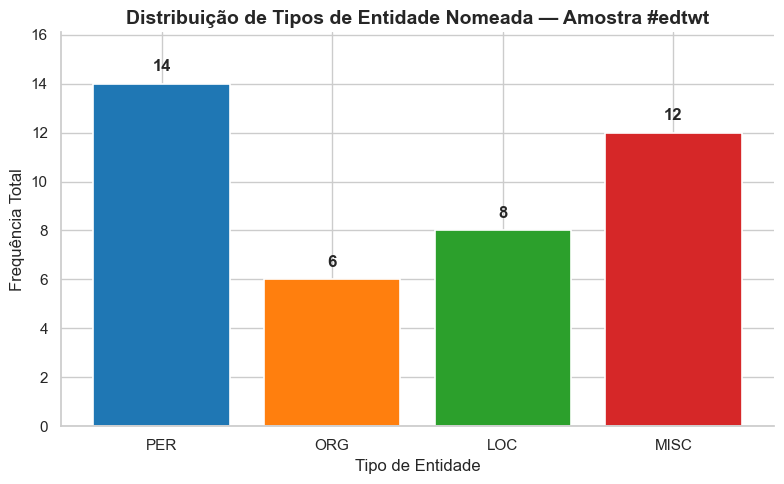

In [8]:
entidades_cols = ["qtde_PER", "qtde_ORG", "qtde_LOC", "qtde_MISC"]
totais_entidades = df_doc_features[entidades_cols].sum()

fig, ax = plt.subplots(figsize=(8, 5))
cores = sns.color_palette("tab10", len(entidades_cols))
bars = ax.bar(
    [c.replace("qtde_", "") for c in entidades_cols],
    totais_entidades,
    color=cores,
    edgecolor="white",
    linewidth=1.2
)

for bar, total in zip(bars, totais_entidades):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(int(total)), ha="center", fontweight="bold")

ax.set_title("Distribuição de Tipos de Entidade Nomeada — Amostra #edtwt",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Entidade")
ax.set_ylabel("Frequência Total")
ax.set_ylim(0, max(totais_entidades) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()